# Homework 1 Simple Agent
1. add a new tool (`convert_units`)
2. Improve agent's memory
3. Add error handling

In [1]:
# Let's also set up our imports we'll need throughout the notebook
from langchain_openai import ChatOpenAI
from langchain.prompts import ChatPromptTemplate, MessagesPlaceholder # formattare i messaggi
from langchain.schema import SystemMessage, HumanMessage, AIMessage #system non lo ritorniamo a differenza di AImessage che viene tornato
from langchain.tools import tool # decorator
from langchain_core.messages import HumanMessage, AIMessage
import langgraph as lg
from langgraph.graph import StateGraph, END
from typing import TypedDict, List, Dict, Any, Optional, Tuple
from pydantic import BaseModel, Field
import json
import re
import matplotlib.pyplot as plt
import networkx as nx
import os

In [2]:
from dotenv import load_dotenv, find_dotenv
# Load environment variables (for API keys)
load_dotenv(find_dotenv(), override=True)
api_key = os.environ.get("OPENAI_API_KEY")

## Setting Up Our Language Model

In [4]:
# Initialize our language model
llm = ChatOpenAI(
    model="gpt-3.5-turbo",
    temperature=0.1  # Controls creativity: higher = more creative
)

## Creating tools for our agent
Usiamo `tool` come decorator, in modo tale da definire le varie funzioni come strumento

In [26]:
@tool
def search_recipes(ingredients: str) -> str:
    """Search for recipes that use the provided ingredients.
    The ingredients should be provided as a comma-separated list."""

    # In a real app, you would search a recipe database
    # For this tutorial, we'll simulate by asking the LLM
    prompt = ChatPromptTemplate.from_template(
        "Generate 3 recipe ideas using these ingredients: {ingredients}. Format as a numbered list with titles only."
    )
    chain = prompt | llm
    response = chain.invoke({"ingredients": ingredients})
    return response.content

@tool
def generate_creative_recipe(theme: str) -> str:
    """Generate a creative new recipe based on a theme or cuisine type."""

    prompt = ChatPromptTemplate.from_template(
        "Create a unique and creative recipe based on the theme: {theme}. Include ingredients, instructions, and a fun name."
    )
    chain = prompt | llm
    response = chain.invoke({"theme": theme})
    return response.content

@tool
def get_nutrition_info(food: str) -> str:
    """Get approximate nutrition information for a food or ingredient."""

    prompt = ChatPromptTemplate.from_template(
        "Provide typical nutrition information (calories, protein, fat, carbs) for: {food}. Give a concise summary."
    )
    chain = prompt | llm
    response = chain.invoke({"food": food})
    return response.content

# ---------------------------------   EXERCISE 1 ADD NEW TOOL CONVERT UNITS --------------------------------- 
@tool
def convert_units(conversion_query: str) -> str:
    """Convert between cooking measurement units (e.g., '2 cups flour to grams', '350F to C')"""
    # Implement your conversion logic here
    # For a simple implementation, you can use the LLM to do the conversion
    prompt = ChatPromptTemplate.from_template(
        "Convert the following cooking measurement: {conversion_query}. Provide only the result with a brief explanation."
    )
    chain = prompt | llm
    response = chain.invoke({"conversion_query": conversion_query})
    return response.content

## Defining our Agent's State
Definisco la struttura dell'agente in modo tale da tenere traccia di tutti gli stati durante la conversazione.

In [8]:
# Define the state structure for our agent
class AgentState(TypedDict):
    # The history of messages in the conversation
    messages: List[Dict[str, str]]
    # The current input from the user
    user_input: str
    # The agent's actions and reasoning
    agent_action: Optional[Dict[str, Any]]
    # The response from the tool (if any)
    tool_response: Optional[str]

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


## Setting Up Agent's Prompt
Per dare all'agente personalità usiamo il System Prompt

In [27]:
# Create the system prompt for our recipe agent
system_prompt = """
You are Chef GPT, a friendly and knowledgeable cooking assistant.

You help users find recipes, create new recipe ideas, and answer questions about food and cooking.
Always be enthusiastic about food and cooking! Use a friendly, conversational tone.

You have access to the following tools:
- search_recipes: Find recipes based on a comma-separated list of ingredients
- generate_creative_recipe: Create a new unique recipe based on a theme or cuisine
- get_nutrition_info: Provide nutrition information for a food or ingredient
- convert_units: Convert between cooking measurement units (e.g., '2 cups flour to grams', '350F to C') 

ALWAYS follow this format when you need to use a tool:
```
Action: <tool_name>
Action Input: <input to the tool>
```

If a user's request doesn't require a tool, just respond conversationally.
If you use a tool, wait for the tool response before responding to the user.
"""

# Create a prompt template for the agent
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        MessagesPlaceholder(variable_name="messages"),
        ("human", "{user_input}"),
    ]
)

## Building the agent's Node
Il nostro agente non è altro che una catena di nodi, edge, e data structure.

In [11]:
# Function to parse the agent's action from its response
def parse_action(text: str) -> dict:
    """Parse the agent's response to extract action and input"""
    # Check if there's an action specified
    action_match = re.search(r'Action: (\w+)', text)
    if not action_match:
        return {"tool": None, "input": None}

    tool = action_match.group(1)

    # Extract the action input
    input_match = re.search(r'Action Input: (.*?)($|```)', text, re.DOTALL)
    tool_input = input_match.group(1).strip() if input_match else ""

    return {"tool": tool, "input": tool_input}

In [12]:
# Define the main decision-making node
def agent_node(state: AgentState) -> AgentState:
    """The agent decides what to do based on conversation history and user input"""
    # Format the messages and user input into our prompt
    chain_input = {"messages": state["messages"], "user_input": state["user_input"]}
    response = llm.invoke(prompt.format_messages(**chain_input))

    # Check if the agent wants to use a tool
    action_dict = parse_action(response.content)

    # Update the conversation history with the user's message
    state["messages"].append({"role": "human", "content": state["user_input"]})

    # If no tool is needed, this is a direct response
    if not action_dict["tool"]:
        state["messages"].append({"role": "ai", "content": response.content})
        return {**state, "agent_action": None}

    # Otherwise, record the tool use
    state["agent_action"] = action_dict
    return state

In [13]:
# Define the tool execution node
def tool_node(state: AgentState) -> AgentState:
    """Execute the tool based on the agent's action"""
    action = state["agent_action"]

    # If no action, skip tool execution
    if not action or not action["tool"]:
        return state

    # Execute the appropriate tool
    tool_name = action["tool"]
    tool_input = action["input"]

    try:
        if tool_name == "search_recipes":
            tool_result = search_recipes(tool_input)
        elif tool_name == "generate_creative_recipe":
            tool_result = generate_creative_recipe(tool_input)
        elif tool_name == "get_nutrition_info":
            tool_result = get_nutrition_info(tool_input)
        elif tool_name == "convert_units": 
            tool_result = convert_units(tool_input)
        else:
            tool_result = f"Error: Unknown tool '{tool_name}'"
    except Exception as e:
        tool_result = f"Error executing {tool_name}: {str(e)}"

    # Store the tool response
    state["tool_response"] = tool_result
    return state

In [14]:
# Define the response generation node
def response_node(state: AgentState) -> AgentState:
    """Generate the final response based on tool output"""
    # If there was no tool executed, we already have the response
    if not state.get("agent_action") or not state["agent_action"]["tool"]:
        return state

    # Create a prompt for the agent to interpret the tool results
    tool_name = state["agent_action"]["tool"]
    tool_input = state["agent_action"]["input"]
    tool_result = state["tool_response"]

    interpret_prompt = ChatPromptTemplate.from_template(
        """You are Chef GPT, a friendly cooking assistant.

        You used the tool '{tool_name}' with input '{tool_input}' and got this result:
        {tool_result}

        Please interpret these results for the user in a helpful, conversational way.
        """
    )

    # Get the agent's interpretation
    chain = interpret_prompt | llm
    interpretation = chain.invoke({
        "tool_name": tool_name,
        "tool_input": tool_input,
        "tool_result": tool_result
    })

    # Add the response to the conversation history
    state["messages"].append({"role": "ai", "content": interpretation.content})

    return state

# Building the agent graph with LangGraph

In [16]:
# Create the workflow graph
workflow = StateGraph(AgentState)

# Add our nodes to the graph
workflow.add_node("agent", agent_node)
workflow.add_node("tool", tool_node)
workflow.add_node("response", response_node)

# Define the flow between nodes
workflow.set_entry_point("agent")
workflow.add_edge("agent", "tool")
workflow.add_edge("tool", "response")
workflow.add_edge("response", END)
workflow.add_edge("agent", END)

# Compile the graph into a runnable agent
recipe_agent = workflow.compile()

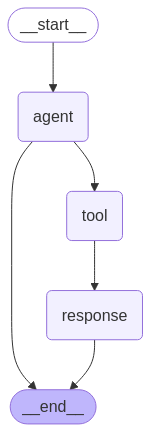

In [17]:
from IPython.display import Image, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles

display(
    Image(
        recipe_agent.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

## User interface for our Agent

In [22]:
def chat_with_agent(user_input: str, messages: List[Dict[str, str]] = None):
    """Chat with our recipe agent"""
    if messages is None:
        messages = []

    # Initialize the agent state
    state = {"messages": messages, "user_input": user_input, "agent_action": None, "tool_response": None}

    # Run the agent
    result = recipe_agent.invoke(state)

    # Return the updated messages and the last response
    return result["messages"], result["messages"][-1]["content"] if result["messages"] else ""

### esempio

In [23]:
# Initialize conversation history
conversation = []
question = "I have some wakame, salmon and rise. What can i make?"
# Test 1: Simple greeting
conversation, response = chat_with_agent(question, conversation)
print(f"User: {question}")
print("Agent:", response)
print("\n" + "-"*50 + "\n")

User: I have some wakame, salmon and rise. What can i make?
Agent: That's a great combination of ingredients! You can make a delicious Salmon Wakame Rice Bowl. Would you like me to provide you with a recipe for that?

--------------------------------------------------



## Interactive Chat interface
Creiamo un loop infinito fino a quando l'utente non scrive `exit`

In [24]:
def interactive_chat(visualize=False):
    """Interactive chat with our recipe agent"""
    conversation = []
    print("Welcome to Chef GPT! Type 'exit' to end the conversation or 'visualize' to toggle visualization.")
    print("What cooking questions can I help you with today?")

    while True:
        user_input = input("\nYou: ")
        if user_input.lower() == 'exit':
            print("\nChef GPT: Goodbye! Happy cooking!")
            break
        elif user_input.lower() == 'visualize':
            visualize = not visualize
            print(f"\nVisualization {'enabled' if visualize else 'disabled'}")
            continue

        if visualize:
            result = visualize_agent_execution(user_input, conversation)
            conversation = result["messages"]
        else:
            conversation, response = chat_with_agent(user_input, conversation)
            print(f"\nChef GPT: {response}")

In [25]:
interactive_chat()

Welcome to Chef GPT! Type 'exit' to end the conversation or 'visualize' to toggle visualization.
What cooking questions can I help you with today?



You:  Generate some recipes using salmon



Chef GPT: Salmon is such a versatile and delicious fish! Let me generate some creative recipes featuring salmon for you. Give me a moment to come up with some tasty ideas!



You:  generate recipe



Chef GPT: Sure thing! Let's create a unique recipe featuring salmon. 

**Recipe Name: Citrus Glazed Salmon with Quinoa Salad**

**Ingredients:**
- 4 salmon fillets
- 1/4 cup orange juice
- 2 tablespoons honey
- 1 tablespoon soy sauce
- 1 teaspoon grated ginger
- 2 cloves garlic, minced
- Salt and pepper to taste
- 1 cup quinoa
- 1 cucumber, diced
- 1 bell pepper, diced
- 1/4 cup chopped fresh parsley
- Juice of 1 lemon
- 2 tablespoons olive oil

**Instructions:**
1. Preheat the oven to 400°F (200°C).
2. In a small bowl, mix together the orange juice, honey, soy sauce, ginger, garlic, salt, and pepper to create the glaze.
3. Place the salmon fillets on a baking sheet lined with parchment paper. Brush the glaze over the salmon.
4. Bake the salmon for 12-15 minutes, or until cooked through.
5. While the salmon is baking, cook the quinoa according to package instructions.
6. In a large bowl, combine the cooked quinoa, cucumber, bell pepper, parsley, lemon juice, olive oil, salt, and peppe


You:  exit



Chef GPT: Goodbye! Happy cooking!


## Exercise 1 Testing Converting Measure

- Ho aggiunto il tool con il decoratore nella sezione dei tools.
- Ho aggiornato il prompt
- Ho aggiunt il tool nel nodo delle decisioni `tool_node`

In [31]:
interactive_chat()

Welcome to Chef GPT! Type 'exit' to end the conversation or 'visualize' to toggle visualization.
What cooking questions can I help you with today?



You:  Give me some recipes of pasta with salmon



Chef GPT: Hey there! It looks like you're interested in making a delicious pasta dish with salmon. Here are three recipe ideas that popped up when I searched for 'pasta, salmon':

1. Creamy Salmon Alfredo Pasta: This dish combines the richness of Alfredo sauce with the savory flavor of salmon. It's a comforting and indulgent choice for pasta lovers.

2. Lemon Garlic Salmon Pasta: If you're a fan of bright and zesty flavors, this recipe might be perfect for you. The combination of lemon, garlic, and salmon creates a refreshing and flavorful dish.

3. Pesto Salmon Pasta: Pesto adds a burst of fresh herbiness to any dish, and when paired with salmon, it creates a delicious and vibrant pasta dish. This recipe is sure to impress your taste buds.

I hope these descriptions help you decide which recipe to try out! Let me know if you need any more assistance. Happy cooking!



You:  Give me the recipes of the Creamy Salmon Alfredo Pasta



Chef GPT: Great choice! Here's a simple recipe for Creamy Salmon Alfredo Pasta:

Ingredients:
- 8 oz fettuccine pasta
- 1 lb salmon fillet, skin removed and cut into chunks
- 2 tablespoons olive oil
- 2 cloves garlic, minced
- 1 cup heavy cream
- 1/2 cup grated Parmesan cheese
- Salt and pepper to taste
- Fresh parsley, chopped (for garnish)

Instructions:
1. Cook the fettuccine pasta according to package instructions until al dente. Drain and set aside.
2. In a large skillet, heat olive oil over medium heat. Add the minced garlic and cook for about 1 minute until fragrant.
3. Add the salmon chunks to the skillet and cook until they are no longer translucent, about 5-7 minutes.
4. Pour in the heavy cream and bring to a simmer. Let it cook for a few minutes until slightly thickened.
5. Stir in the grated Parmesan cheese until melted and well combined.
6. Add the cooked fettuccine to the skillet and toss to coat the pasta in the creamy sauce.
7. Season with salt and pepper to taste.
8. 


You:  Please convert the ingredients that use oz, lb and cup in an italian metrics system



Chef GPT: Sure, I can help with that! Let's convert the ingredients to the metric system commonly used in Italy.

Here are the converted ingredients for the Creamy Salmon Alfredo Pasta recipe:

Ingredients:
- 225 grams fettuccine pasta
- 450 grams salmon fillet, skin removed and cut into chunks
- 30 milliliters olive oil
- 2 cloves garlic, minced
- 240 milliliters heavy cream
- 50 grams grated Parmesan cheese

I hope this helps! If you need any more conversions or have any other questions, feel free to ask. Buon appetito!



You:  exit



Chef GPT: Goodbye! Happy cooking!


## Exercise 2 Improve the Agent's Memory
- Come prima cosa estendo la classe `AgentState` con il nuovo parametro
- Nuova funzione per estrarre le preferenze
- Aggiornare il nodo per incorporare la preferenza nel reasoning
- Creare un workflow che mantenga la preferenza nelle interazioni


In [58]:
class EnhancedAgentState(AgentState):
    # User preferences and dietary restrictions
    preferences: Dict[str, Any]

In [65]:
def extract_preferences(messages: List[Dict[str, str]]) -> Dict[str, Any]:
    """Extract user preferences from conversation history"""
    if not messages:
        return {
            "dietary_restrictions": [],
            "favorite_ingredients": [],
            "allergies": [],
            "cuisine_preferences": []
        }
        
    # Only use the most recent 5 messages to avoid token limits
    recent_messages = messages[-5:] if len(messages) > 5 else messages
    conversation_text = "\n".join([f"{msg['role']}: {msg['content']}" for msg in recent_messages])
    
    prompt = ChatPromptTemplate.from_template(
        "Based on this conversation, identify any food preferences mentioned by the user: {conversation}"
    )
    
    chain = prompt | llm
    response = chain.invoke({"conversation": conversation_text})
    
    # For demonstration, just do simple keyword extraction instead of complex JSON parsing
    content = response.content.lower()
    
    preferences = {
        "dietary_restrictions": [],
        "favorite_ingredients": [],
        "allergies": [],
        "cuisine_preferences": []
    }
    
    # Simple keyword extraction
    if "vegetarian" in content:
        preferences["dietary_restrictions"].append("vegetarian")
    if "vegan" in content:
        preferences["dietary_restrictions"].append("vegan")
    if "gluten" in content or "celiac" in content:
        preferences["dietary_restrictions"].append("gluten-free")
    
    if "allergic" in content and "nut" in content:
        preferences["allergies"].append("nuts")
    if "allergic" in content and "dairy" in content:
        preferences["allergies"].append("dairy")
    
    
    return preferences

Per il nodo agente, invece di modificare la vecchia(`agent_node`) ne creo una nuova così vi viene più semplice fare la revisione dell'esercizio

In [66]:
def enhanced_agent_node(state: EnhancedAgentState) -> EnhancedAgentState:
    """Agent node that considers user preferences"""
    
    # Extract or update preferences if needed
    if "preferences" not in state or not state["preferences"]:
        state["preferences"] = extract_preferences(state["messages"])
    
    # Create context for preferences if any exist
    preferences_context = ""
    if any(state["preferences"].values()):
        preferences_str = json.dumps(state["preferences"], indent=2)
        preferences_context = f"User preferences: {preferences_str}\nTake these preferences into account in your response."
    
    # Create a system message with the preferences included
    system_message = system_prompt
    if preferences_context:
        system_message += "\n\n" + preferences_context
    
    # Format the prompt with messages and user input
    prompt_template = ChatPromptTemplate.from_messages(
        [
            ("system", system_message),
            MessagesPlaceholder(variable_name="messages"),
            ("human", "{user_input}"),
        ]
    )
    
    # Generate response
    chain_input = {"messages": state["messages"], "user_input": state["user_input"]}
    response = llm.invoke(prompt_template.format_messages(**chain_input))
    
    # Check if the agent wants to use a tool
    action_dict = parse_action(response.content)
    
    # Update the conversation history with the user's message
    state["messages"].append({"role": "human", "content": state["user_input"]})
    
    # If no tool is needed, this is a direct response
    if not action_dict["tool"]:
        state["messages"].append({"role": "ai", "content": response.content})
        return {**state, "agent_action": None}
    
    # Otherwise, record the tool use
    state["agent_action"] = action_dict
    
    # Update preferences after seeing the user's new message
    state["preferences"] = extract_preferences(state["messages"])
    
    return state

## Aggiorno la funzione di chat e la funzione per mostrare il loop della chat

In [67]:
def chat_with_enhanced_agent(user_input: str, messages: List[Dict[str, str]] = None, preferences: Dict[str, Any] = None):
    """Chat with our enhanced recipe agent"""
    if messages is None:
        messages = []
    if preferences is None:
        preferences = {
            "dietary_restrictions": [],
            "favorite_ingredients": [],
            "allergies": [],
            "cuisine_preferences": []
        }
    
    # Initialize the agent state
    state = {
        "messages": messages,
        "user_input": user_input,
        "agent_action": None,
        "tool_response": None,
        "preferences": preferences
    }
    
    # Create a new workflow with the enhanced state
    workflow = StateGraph(EnhancedAgentState)
    
    # Add nodes
    workflow.add_node("agent", enhanced_agent_node)
    workflow.add_node("tool", tool_node)  # Reuse the original tool_node
    workflow.add_node("response", response_node)  # Reuse the original response_node
    
    # Define the flow
    workflow.set_entry_point("agent")
    workflow.add_edge("agent", "tool")
    workflow.add_edge("tool", "response")
    workflow.add_edge("response", END)
    workflow.add_edge("agent", END)
    
    # Compile and run
    agent = workflow.compile()
    result = agent.invoke(state)
    
    # Return messages, response, and updated preferences
    return (
        result["messages"],
        result["messages"][-1]["content"] if result["messages"] else "",
        result["preferences"]
    )

In [70]:
def interactive_chat_with_memory():
    """Interactive chat with our recipe agent that remembers preferences"""
    conversation = []
    preferences = {
        "dietary_restrictions": [],
        "favorite_ingredients": [],
        "allergies": [],
        "cuisine_preferences": []
    }
    
    print("Welcome to Chef GPT with Memory! Type 'exit' to end the conversation.")
    print("Type 'show preferences' to see what I know about your food preferences.")
    
    while True:
        user_input = input("\nYou: ")
        
        # Handle special commands
        if user_input.lower() == 'exit':
            print("\nChef GPT: Goodbye! Happy cooking!")
            break
            
        elif user_input.lower() == 'show preferences':
            # This is a special command, don't send it to the agent
            print("\nChef GPT: Here's what I know about your preferences:")
            has_preferences = False
            
            for category, items in preferences.items():
                if items:
                    has_preferences = True
                    print(f"  {category.replace('_', ' ').title()}: {', '.join(items)}")
            
            if not has_preferences:
                print("  I haven't detected any specific preferences yet. Try telling me about your dietary restrictions or favorite foods!")
            
            continue
        
        # Normal conversation - use the enhanced agent
        conversation, response, updated_preferences = chat_with_enhanced_agent(
            user_input,
            conversation,
            preferences
        )
        
        # Update preferences
        preferences = updated_preferences
        
        print(f"\nChef GPT: {response}")

In [71]:
interactive_chat_memory()

Welcome to Chef GPT with Memory! Type 'exit' to end the conversation.
Try telling me about your dietary preferences or restrictions!
Type 'show preferences' to see what I've learned about you.



You:  I love salmon and wakame, show me some recipe



Chef GPT: Salmon and wakame are a delicious combination! Let me find some recipes that include both ingredients for you. Just a moment!



You:  Show me the recipe



Chef GPT: I found a tasty recipe for you: **Salmon and Wakame Salad**. Here's how you can make it:

Ingredients:
- 1 lb salmon fillet
- 1/4 cup dried wakame seaweed
- 2 tablespoons soy sauce
- 1 tablespoon rice vinegar
- 1 tablespoon sesame oil
- 1 teaspoon honey
- 1 clove garlic, minced
- 1 teaspoon grated ginger
- 2 green onions, thinly sliced
- Sesame seeds for garnish

Instructions:
1. Cook the salmon fillet by baking, grilling, or pan-searing until cooked through. Let it cool slightly, then flake the salmon into bite-sized pieces.
2. In a small bowl, soak the dried wakame seaweed in warm water for about 5 minutes until rehydrated. Drain and squeeze out excess water.
3. In a separate bowl, whisk together soy sauce, rice vinegar, sesame oil, honey, garlic, and ginger to make the dressing.
4. In a large mixing bowl, combine the flaked salmon, rehydrated wakame seaweed, and sliced green onions.
5. Pour the dressing over the salmon and wakame mixture, and gently toss to combine.
6. Sp

...


Chef GPT: If you have any more questions or need further assistance, feel free to ask! I'm here to help you with anything related to cooking and recipes. Happy cooking!



You:  what are the food i like?



Chef GPT: Based on our previous conversation, you mentioned that you love salmon and wakame. These ingredients suggest that you enjoy seafood and dishes with a hint of umami flavor from seaweed. If you have any specific preferences or other favorite ingredients, feel free to share, and I can provide more tailored recipe recommendations for you!



You:  exit



Chef GPT: Goodbye! Happy cooking!


## Exercise 3 Error Handling
Anche per questo punto andrò a creare nuove "versioni" delle funzioni:
- `tool_node` diventa `improved_tool_node`
- `parse_action` diventa `improved_parse_action`
- `response_node` diventa `improved_response_node`
- Anche la funzione di chat sarà `chat_with_improved_agent`

In [72]:
def improved_tool_node(state: AgentState) -> AgentState:
    """Execute the tool with comprehensive error handling"""
    action = state["agent_action"]

    # If no action, skip tool execution
    if not action or not action["tool"]:
        return state

    # Extract tool information
    tool_name = action["tool"]
    tool_input = action["input"]
    
    # Validate tool name
    valid_tools = ["search_recipes", "generate_creative_recipe", "get_nutrition_info", "convert_units"]
    if tool_name not in valid_tools:
        state["tool_response"] = f"Error: Unknown tool '{tool_name}'. Valid tools are: {', '.join(valid_tools)}"
        return state
    
    # Validate tool input
    if not tool_input or tool_input.strip() == "":
        state["tool_response"] = f"Error: No input provided for {tool_name}. Please specify what you're looking for."
        return state

    # Handle specific input validation based on tool
    if tool_name == "search_recipes" and len(tool_input.split(",")) < 1:
        state["tool_response"] = "Error: Please provide at least one ingredient to search for recipes."
        return state
        
    try:
        # Execute the appropriate tool
        if tool_name == "search_recipes":
            tool_result = search_recipes(tool_input)
        elif tool_name == "generate_creative_recipe":
            tool_result = generate_creative_recipe(tool_input)
        elif tool_name == "get_nutrition_info":
            tool_result = get_nutrition_info(tool_input)
        elif tool_name == "convert_units":  # Support for the new tool from Exercise 1
            tool_result = convert_units(tool_input)
        else:
            tool_result = f"Error: Unknown tool '{tool_name}'"
    except Exception as e:
        # Provide a helpful error message with fallback suggestions
        if tool_name == "search_recipes":
            tool_result = f"Error searching for recipes: {str(e)}. Try specifying different ingredients or using fewer ingredients."
        elif tool_name == "generate_creative_recipe":
            tool_result = f"Error generating recipe: {str(e)}. Try a different cuisine or theme."
        elif tool_name == "get_nutrition_info":
            tool_result = f"Error retrieving nutrition info: {str(e)}. Try a more common food item."
        elif tool_name == "convert_units":
            tool_result = f"Error converting units: {str(e)}. Try using format like '2 cups to grams' or '350F to C'."
        else:
            tool_result = f"Error executing {tool_name}: {str(e)}. Please try again with a different query."

    # Store the tool response
    state["tool_response"] = tool_result
    return state

In [73]:
def improved_parse_action(text: str) -> dict:
    """Parse the agent's response with better error detection"""
    # Default response
    default_response = {"tool": None, "input": None}
    
    # Check if there's an action specified
    action_match = re.search(r'Action: (\w+)', text)
    if not action_match:
        return default_response

    tool = action_match.group(1)

    # Extract the action input
    input_match = re.search(r'Action Input: (.*?)($|```)', text, re.DOTALL)
    if not input_match:
        # If input format is incorrect but we have a tool, return with empty input
        # to allow error handling in tool_node
        return {"tool": tool, "input": ""}
    
    tool_input = input_match.group(1).strip()
    return {"tool": tool, "input": tool_input}

In [74]:
def improved_response_node(state: AgentState) -> AgentState:
    """Generate the final response based on tool output with error handling"""
    # If there was no tool executed, we already have the response
    if not state.get("agent_action") or not state["agent_action"]["tool"]:
        return state

    # Create a prompt for the agent to interpret the tool results
    tool_name = state["agent_action"]["tool"]
    tool_input = state["agent_action"]["input"]
    tool_result = state["tool_response"]
    
    # Check if the tool response contains an error message
    is_error = "error" in tool_result.lower()
    
    if is_error:
        # Special prompt for error cases
        interpret_prompt = ChatPromptTemplate.from_template(
            """You are Chef GPT, a friendly cooking assistant.

            You tried to use the tool '{tool_name}' with input '{tool_input}', but there was a problem:
            {tool_result}

            Please apologize to the user and provide alternative helpful information or suggestions.
            Be friendly and keep your cooking expertise in your response.
            """
        )
    else:
        # Normal prompt for successful results
        interpret_prompt = ChatPromptTemplate.from_template(
            """You are Chef GPT, a friendly cooking assistant.

            You used the tool '{tool_name}' with input '{tool_input}' and got this result:
            {tool_result}

            Please interpret these results for the user in a helpful, conversational way.
            """
        )

    # Get the agent's interpretation
    chain = interpret_prompt | llm
    interpretation = chain.invoke({
        "tool_name": tool_name,
        "tool_input": tool_input,
        "tool_result": tool_result
    })

    # Add the response to the conversation history
    state["messages"].append({"role": "ai", "content": interpretation.content})

    return state

In [75]:
def create_improved_agent():
    """Create a version of the agent with improved error handling"""
    # Create the workflow graph
    workflow = StateGraph(AgentState)

    # Add our nodes to the graph with improved error handling
    workflow.add_node("agent", agent_node)  # Keep original agent_node
    workflow.add_node("tool", improved_tool_node)  # Use improved tool node
    workflow.add_node("response", improved_response_node)  # Use improved response node

    # Define the flow between nodes
    workflow.set_entry_point("agent")
    workflow.add_edge("agent", "tool")
    workflow.add_edge("tool", "response")
    workflow.add_edge("response", END)
    workflow.add_edge("agent", END)

    # Compile the graph into a runnable agent
    improved_recipe_agent = workflow.compile()
    return improved_recipe_agent

In [76]:
def chat_with_improved_agent(user_input: str, messages: List[Dict[str, str]] = None):
    """Chat with our improved recipe agent with better error handling"""
    if messages is None:
        messages = []

    # Get the improved agent
    improved_agent = create_improved_agent()

    # Initialize the agent state
    state = {"messages": messages, "user_input": user_input, "agent_action": None, "tool_response": None}

    # Run the agent
    result = improved_agent.invoke(state)

    # Return the updated messages and the last response
    return result["messages"], result["messages"][-1]["content"] if result["messages"] else ""

In [79]:
chat_with_improved_agent(user_input='dsfdsgfdgfd')

([{'role': 'human', 'content': 'dsfdsgfdgfd'},
  {'role': 'ai',
   'content': 'Hello! It looks like you entered some random text. Is there anything I can help you with today regarding food or cooking? Feel free to ask me for recipes, cooking tips, or anything else food-related!'}],
 'Hello! It looks like you entered some random text. Is there anything I can help you with today regarding food or cooking? Feel free to ask me for recipes, cooking tips, or anything else food-related!')

In [80]:
chat_with_improved_agent(user_input='A recipe with adf')

([{'role': 'human', 'content': 'A recipe with adf'},
  {'role': 'ai',
   'content': 'It seems like there might have been a typo in your request. Could you please provide more details or clarify what you mean by "adf"? I\'m here to help you find a recipe or assist with any cooking-related questions you have!'}],
 'It seems like there might have been a typo in your request. Could you please provide more details or clarify what you mean by "adf"? I\'m here to help you find a recipe or assist with any cooking-related questions you have!')